In [ ]:
# Módulo 4 sesión 2
# Importamos las librerías necesarias
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import files

# Abre el diálogo para subir el archivo
uploaded = files.upload()
# Reemplaza con el nombre correcto del archivo si es distinto
df = pd.read_csv("StudentsPerformance_sample.csv")

# Visualiza las primeras filas
df.head()

Saving StudentsPerformance_sample.csv to StudentsPerformance_sample.csv


,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [ ]:
# Configuración de estilo para gráficos
sns.set(style="whitegrid")

In [ ]:
# Verificamos la estructura y tipos de datos
df.info()

# Estadísticas básicas de las variables numéricas
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       10 non-null     object
 1   race/ethnicity               10 non-null     object
 2   parental level of education  10 non-null     object
 3   lunch                        10 non-null     object
 4   test preparation course      10 non-null     object
 5   math score                   10 non-null     int64 
 6   reading score                10 non-null     int64 
 7   writing score                10 non-null     int64 
dtypes: int64(3), object(5)
memory usage: 772.0+ bytes


,math score,reading score,writing score
count,10.000000,10.00000,10.000000
mean,65.500000,73.70000,70.000000
std,18.416478,17.58819,19.686431
min,38.000000,43.00000,39.000000
25%,51.250000,61.00000,54.250000
50%,70.000000,75.00000,74.500000
75%,75.000000,88.25000,85.500000
max,90.000000,95.00000,93.000000


In [ ]:
# Verificar si hay valores nulos
print(df.isnull().sum())

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64


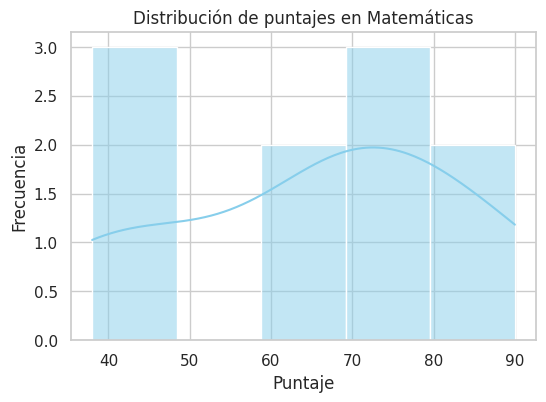

In [ ]:
# Histograma de las puntuaciones en matemáticas
plt.figure(figsize=(6, 4))
sns.histplot(df['math score'], kde=True, color='skyblue')
plt.title('Distribución de puntajes en Matemáticas')
plt.xlabel('Puntaje')
plt.ylabel('Frecuencia')
plt.show()

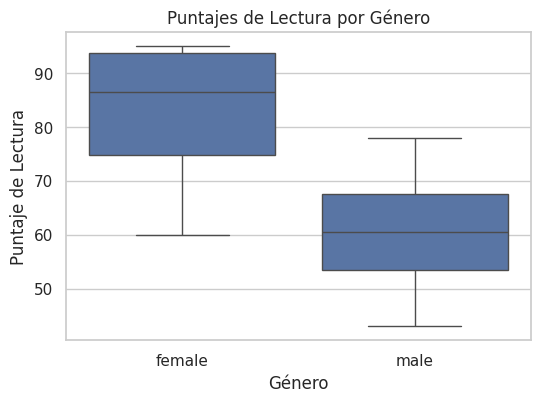

In [ ]:
# Boxplot de puntajes de lectura según el género
plt.figure(figsize=(6, 4))
sns.boxplot(x='gender', y='reading score', data=df)
plt.title('Puntajes de Lectura por Género')
plt.xlabel('Género')
plt.ylabel('Puntaje de Lectura')
plt.show()

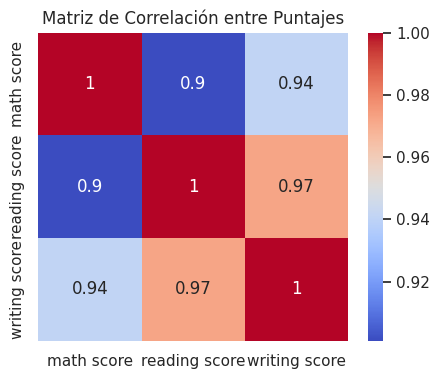

In [ ]:
# Mapa de calor con las correlaciones entre puntajes
plt.figure(figsize=(5, 4))
sns.heatmap(df[['math score', 'reading score', 'writing score']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación entre Puntajes')
plt.show()

In [ ]:
# 3. Explorar estructura inicial
print("Columnas del dataset:", df.columns.to_list())
print("\nPrimeras filas:")
print(df.head())
print("\nTipos de datos:")
print(df.dtypes)

Columnas del dataset: ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']

Primeras filas:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76         

In [ ]:
# 4. Identificar tipos de variables (manual para este ejemplo)
# Categóricas: gender, race/ethnicity, parental level of education, lunch, test preparation course
# Cuantitativas: math score, reading score, writing score

# 5. Tablas de frecuencia (para variable categórica: 'gender')  Variables Categóricas Nominales
print("\nTabla de frecuencia absoluta (gender):")
print(df['gender'].value_counts())

print("\nTabla de frecuencia relativa (gender):")
print(df['gender'].value_counts(normalize=True).round(2))

# Frecuencia relativa porcentual
print("\nFrecuencia relativa:")
print(df['gender'].value_counts(normalize=True).round(2) * 100)



Tabla de frecuencia absoluta (gender):
gender
female    6
male      4
Name: count, dtype: int64

Tabla de frecuencia relativa (gender):
gender
female    0.6
male      0.4
Name: proportion, dtype: float64

Frecuencia relativa:
gender
female    60.0
male      40.0
Name: proportion, dtype: float64


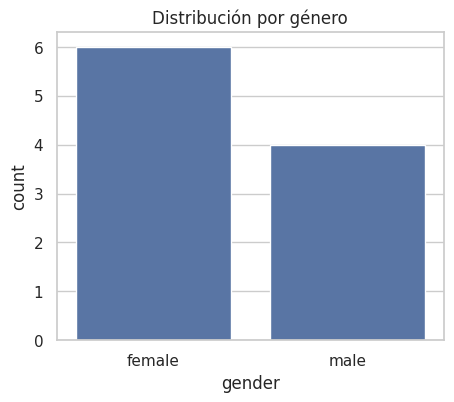

In [ ]:
# Gráfico de barras
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(5, 4))
sns.countplot(x='gender', data=df)
plt.title("Distribución por género")
plt.show()

Frecuencia ordenada:
parental level of education
some high school      0
high school           2
some college          4
associate's degree    2
bachelor's degree     1
master's degree       1
Name: count, dtype: int64


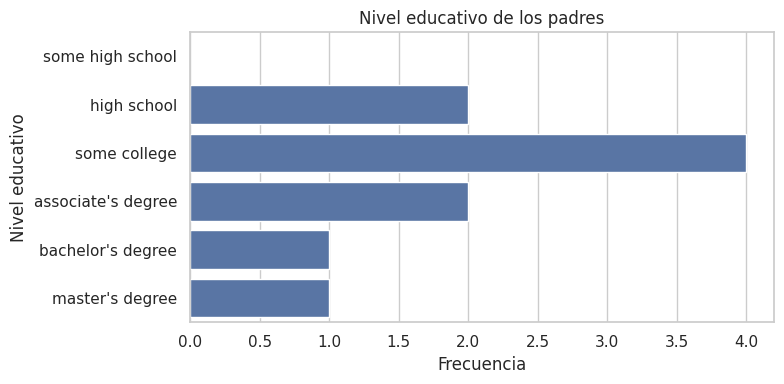

In [ ]:
# Variables categóricas ordinales
# Ejemplo: Ordenar y visualizar “parental level of education”
# Definir el orden lógico para la variable ordinal
orden_educacion = [
    "some high school",
    "high school",
    "some college",
    "associate's degree",
    "bachelor's degree",
    "master's degree"
]

# Convertir a tipo categórico ordenado
df['parental level of education'] = pd.Categorical(
    df['parental level of education'],
    categories=orden_educacion,
    ordered=True
)

# Visualizar frecuencias
print("Frecuencia ordenada:")
print(df['parental level of education'].value_counts().sort_index())

# Gráfico
plt.figure(figsize=(8, 4))
sns.countplot(y='parental level of education', data=df, order=orden_educacion)
plt.title("Nivel educativo de los padres")
plt.xlabel("Frecuencia")
plt.ylabel("Nivel educativo")
plt.tight_layout()
plt.show()

In [ ]:
# 6. Medidas de tendencia central para 'math score'
print("\nMedia:", df['math score'].mean())
print("Mediana:", df['math score'].median())
print("Moda:", df['math score'].mode().values[0])


Media: 65.5
Mediana: 70.0
Moda: 38


In [ ]:
# 7. Medidas de dispersión
print("\nDesviación estándar:", df['math score'].std())
print("Varianza:", df['math score'].var())
print("Rango:", df['math score'].max() - df['math score'].min())


Desviación estándar: 18.41647812874836
Varianza: 339.1666666666667
Rango: 52


In [ ]:
# 8. Cálculo de cuartiles y percentiles
import numpy as np
Q1 = np.percentile(df['math score'], 25)
Q3 = np.percentile(df['math score'], 75)
IQR = Q3 - Q1
print("\nQ1:", Q1, "Q3:", Q3, "IQR:", IQR)


Q1: 51.25 Q3: 75.0 IQR: 23.75


In [ ]:
# 9. Detección de outliers en math score usando método IQR
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df['math score'] < lower_bound) | (df['math score'] > upper_bound)]
print("\nOutliers detectados en math score:\n", outliers)


Outliers detectados en math score:
 Empty DataFrame
Columns: [gender, race/ethnicity, parental level of education, lunch, test preparation course, math score, reading score, writing score]
Index: []


In [ ]:
for col in ['math score', 'reading score', 'writing score']:
    Q1 = np.percentile(df[col], 25)
    Q3 = np.percentile(df[col], 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Outliers en {col}:\n", outliers[['gender', col]])
    print("-" * 40)

Outliers en math score:
 Empty DataFrame
Columns: [gender, math score]
Index: []
----------------------------------------
Outliers en reading score:
 Empty DataFrame
Columns: [gender, reading score]
Index: []
----------------------------------------
Outliers en writing score:
 Empty DataFrame
Columns: [gender, writing score]
Index: []
----------------------------------------


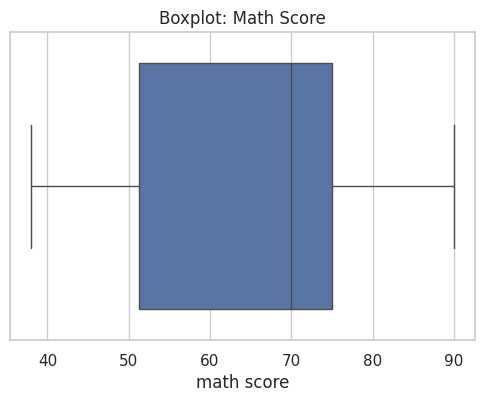

In [ ]:
# 10. Visualización de datos
# 10.1 Boxplot
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['math score'])
plt.title("Boxplot: Math Score")
plt.show()

Caja (box):

Representa el rango intercuartílico (IQR), es decir, los valores entre el primer cuartil (Q1 ≈ 57) y el tercer cuartil (Q3 ≈ 78).

Indica dónde se concentra el 50% de los datos.

Línea dentro de la caja:

Es la mediana de la puntuación en matemáticas, que parece estar cerca de 68 o 70.

"Bigotes" (whiskers):

Se extienden desde Q1 hasta el menor valor dentro del rango permitido (no menor que Q1 − 1.5·IQR), y desde Q3 hasta el mayor valor permitido (no mayor que Q3 + 1.5·IQR).

En tu gráfico, no hay puntos fuera de los bigotes, lo que confirma que no hay outliers.

Simetría:

El boxplot luce ligeramente sesgado hacia la izquierda, porque la caja está algo más cercana al valor máximo que al mínimo.

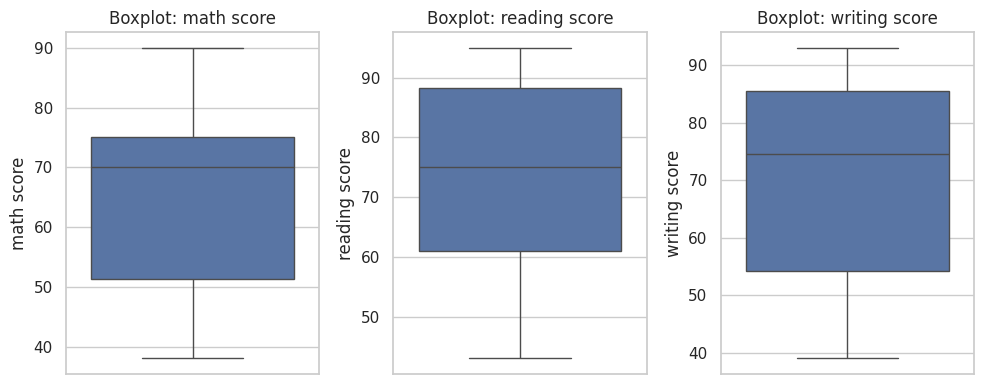

In [ ]:
# Boxplots para cada puntuación
plt.figure(figsize=(10, 4))
for i, col in enumerate(['math score', 'reading score', 'writing score']):
    plt.subplot(1, 3, i+1)
    sns.boxplot(y=df[col])
    plt.title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

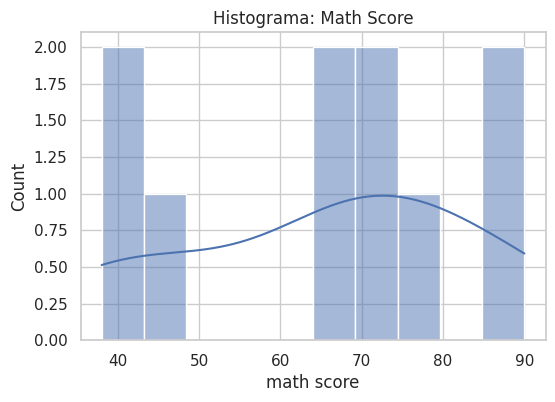

In [ ]:
# 10.2 Histograma
plt.figure(figsize=(6, 4))
sns.histplot(df['math score'], kde=True, bins=10)
plt.title("Histograma: Math Score")
plt.show()

Barras del histograma:

Muestran la frecuencia absoluta de los valores de math score agrupados por intervalos.

Puedes observar que los datos están algo dispersos pero concentrados entre 60 y 90 puntos.

Hay menos estudiantes con puntuaciones bajas (alrededor de 40) y más en los rangos intermedios-altos.

Curva de densidad (KDE):

Representa una estimación suave de la distribución de la variable.

La curva no es perfectamente simétrica; tiene un ligero sesgo negativo (hacia la izquierda) porque hay algunas puntuaciones bajas (≈38 y ≈41) que “jalan” la cola.

Forma general:

No es normal (no es una campana simétrica).

Hay multimodalidad incipiente (varios picos), probablemente por la pequeña cantidad de datos.

Hay indicios de que la distribución podría ser asimétrica o tener valores extremos leves, pero sin outliers extremos (como vimos en el boxplot).

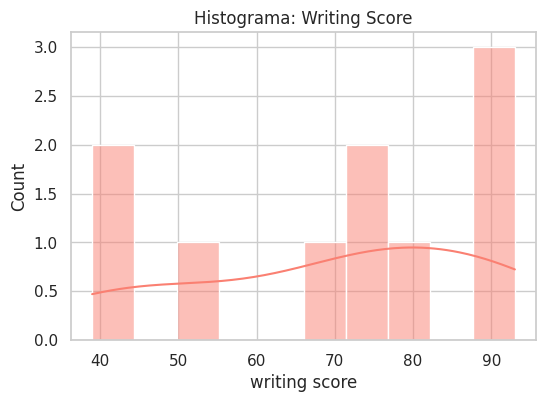

In [ ]:
# Estilo general
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

# 5. Histograma + KDE para writing score
plt.figure(figsize=(6, 4))
sns.histplot(df['writing score'], kde=True, bins=10, color='salmon')
plt.title("Histograma: Writing Score")
plt.xlabel("writing score")
plt.ylabel("Count")
plt.show()

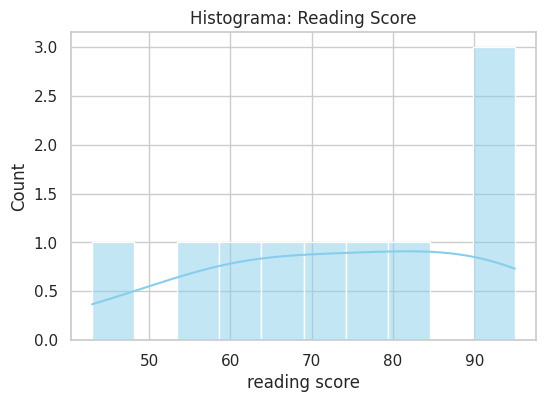

In [ ]:
# 4. Histograma + KDE para reading score
plt.figure(figsize=(6, 4))
sns.histplot(df['reading score'], kde=True, bins=10, color='skyblue')
plt.title("Histograma: Reading Score")
plt.xlabel("reading score")
plt.ylabel("Count")
plt.show()

In [ ]:
# Promedio de escritura por género y curso de preparación
# Promedio por género
print("Promedio de writing score por género:")
print(df.groupby("gender")["writing score"].mean())

# Promedio por test preparation course
print("\nPromedio de writing score por curso de preparación:")
print(df.groupby("test preparation course")["writing score"].mean())


Promedio de writing score por género:
gender
female    79.166667
male      56.250000
Name: writing score, dtype: float64

Promedio de writing score por curso de preparación:
test preparation course
completed    82.333333
none         64.714286
Name: writing score, dtype: float64


Las estudiantes mujeres tienen un promedio significativamente más alto en la puntuación de escritura (casi 80 puntos).

Los estudiantes varones tienen un promedio de 56.25 puntos, lo que indica una brecha de más de 20 puntos respecto a las mujeres.
En esta muestra, el rendimiento en escritura favorece claramente al género femenino.

Los estudiantes que completaron el curso de preparación para el examen tienen una media en escritura muy alta (82.33).

En cambio, los que no realizaron ningún curso obtuvieron un promedio casi 18 puntos menor.

Conclusión: El curso de preparación tiene un impacto positivo claro en el rendimiento de los estudiantes, al menos en la escritura.

In [ ]:
import numpy as np

# Calcular el coeficiente de variación para cada variable numérica
cv_math = df['math score'].std() / df['math score'].mean()
cv_reading = df['reading score'].std() / df['reading score'].mean()
cv_writing = df['writing score'].std() / df['writing score'].mean()

# Mostrar los resultados en porcentaje
print(f"Coeficiente de variación - Math Score: {cv_math:.2%}")
print(f"Coeficiente de variación - Reading Score: {cv_reading:.2%}")
print(f"Coeficiente de variación - Writing Score: {cv_writing:.2%}")

Coeficiente de variación - Math Score: 28.12%
Coeficiente de variación - Reading Score: 23.86%
Coeficiente de variación - Writing Score: 28.12%


Coeficiente de variación de 28.12% en Math y Writing Score
→ Significa que la variabilidad de las puntuaciones en Matemática y Escritura es moderada, y representa aproximadamente el 28% de su valor promedio.
Esto indica que los puntajes están relativamente dispersos alrededor de la media.

Coeficiente de variación de 23.86% en Reading Score
→ La variabilidad en Lectura es ligeramente menor, lo cual sugiere que las puntuaciones están más concentradas en torno al promedio comparado con las otras dos áreas.

Conclusión:
Reading Score es la variable más consistente o menos dispersa.

Math Score y Writing Score presentan un nivel de dispersión ligeramente mayor, pero bastante similar entre sí.

Esto podría indicar que, en esta muestra, la habilidad de lectura es más homogénea, mientras que existen más diferencias individuales en matemática y escritura.

In [ ]:
# Variable a analizar
columna = 'math score'

# Número de clases (Sturges)
k = int(np.ceil(1 + 3.322 * np.log10(len(df))))
# len(df): número total de observaciones.
# np.log10(...): logaritmo base 10.
# np.ceil(...): redondea hacia arriba.
rango = df[columna].max() - df[columna].min()
amplitud = np.ceil(rango / k)

# Crear clases
bins = np.arange(df[columna].min(), df[columna].max() + amplitud, amplitud) # bins: bordes de los intervalos
labels = [f"[{int(bins[i])}, {int(bins[i+1])})" for i in range(len(bins)-1)] # labels: etiquetas de texto para mostrar los intervalos.
df['clase'] = pd.cut(df[columna], bins=bins, labels=labels, include_lowest=True) # pd.cut(...): agrupa los datos según los intervalos definidos.

# Tabla de frecuencias
tabla = df['clase'].value_counts().sort_index().reset_index() # Se ordenan por intervalo (sort_index()).
# Se renombran las columnas como Clase y frec_abs (frecuencia absoluta).
tabla.columns = ['Clase', 'frec_abs']
tabla['frec_rel'] = (tabla['frec_abs'] / tabla['frec_abs'].sum()).round(4)
tabla['frec_acum'] = tabla['frec_abs'].cumsum()
tabla['frec_rel_acum'] = tabla['frec_rel'].cumsum().round(4)

# Mostrar la tabla
print(tabla)

      Clase  frec_abs  frec_rel  frec_acum  frec_rel_acum
0  [38, 49)         3       0.3          3            0.3
1  [49, 60)         0       0.0          3            0.3
2  [60, 71)         3       0.3          6            0.6
3  [71, 82)         2       0.2          8            0.8
4  [82, 93)         2       0.2         10            1.0


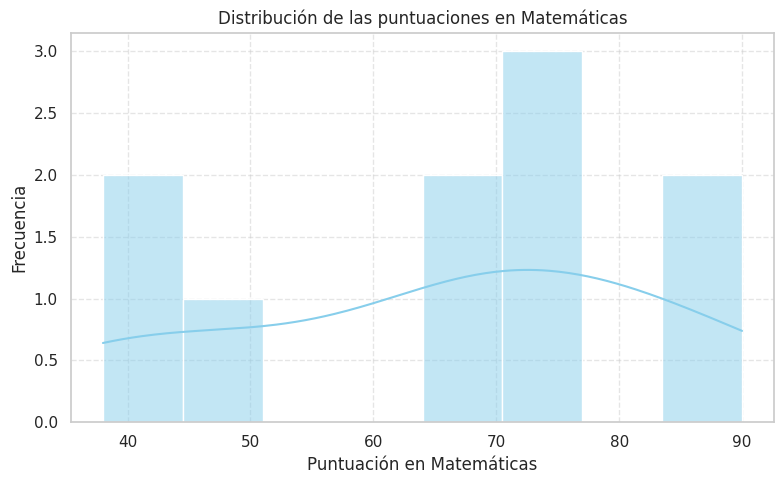

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
# Crear histograma para 'math score'
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='math score', bins=8, kde=True, color='skyblue')

# Personalización del gráfico
plt.title('Distribución de las puntuaciones en Matemáticas')
plt.xlabel('Puntuación en Matemáticas')
plt.ylabel('Frecuencia')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Ejemplo de clases
import pandas as pd

# Datos de ejemplo: Calificaciones de un grupo de estudiantes
datos = [7, 8, 6, 9, 7, 6, 8, 9, 7, 8, 7, 9, 6, 7, 8]

# Crear un DataFrame
df = pd.DataFrame(datos, columns=["Calificación"])

# Crear la tabla de frecuencias
tabla_frecuencia = df["Calificación"].value_counts().sort_index().to_frame("Frecuencia Absoluta")
tabla_frecuencia["Frecuencia Relativa"] = tabla_frecuencia["Frecuencia Absoluta"] / tabla_frecuencia["Frecuencia Absoluta"].sum()
tabla_frecuencia["Frecuencia Acumulada"] = tabla_frecuencia["Frecuencia Absoluta"].cumsum()
tabla_frecuencia["Frecuencia Relativa Acumulada"] = tabla_frecuencia["Frecuencia Relativa"].cumsum()

# Mostrar la tabla de frecuencias
print(tabla_frecuencia)

              Frecuencia Absoluta  Frecuencia Relativa  Frecuencia Acumulada  \
Calificación                                                                   
6                               3             0.200000                     3   
7                               5             0.333333                     8   
8                               4             0.266667                    12   
9                               3             0.200000                    15   

              Frecuencia Relativa Acumulada  
Calificación                                 
6                                  0.200000  
7                                  0.533333  
8                                  0.800000  
9                                  1.000000  


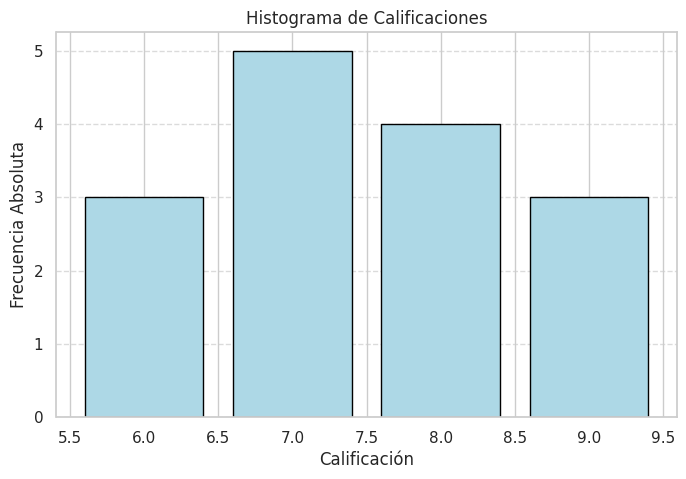

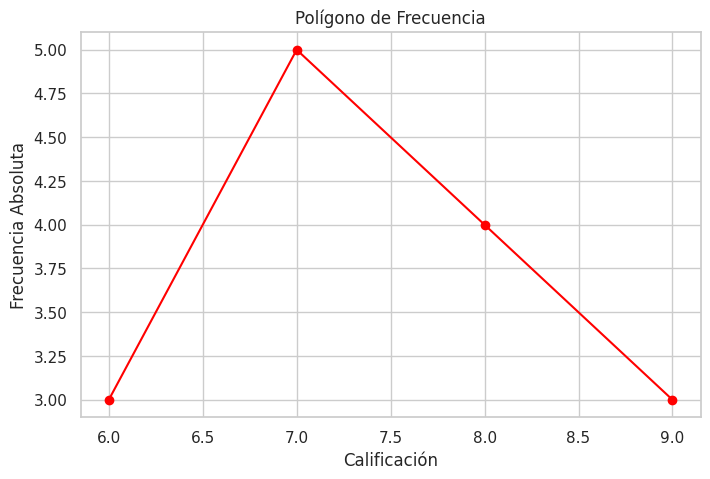

In [ ]:
# Histograma
plt.figure(figsize=(8, 5))
plt.bar(tabla_frecuencia.index, tabla_frecuencia["Frecuencia Absoluta"], color='lightblue', edgecolor='black')
plt.title("Histograma de Calificaciones")
plt.xlabel("Calificación")
plt.ylabel("Frecuencia Absoluta")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Polígono de frecuencia
plt.figure(figsize=(8, 5))
plt.plot(tabla_frecuencia.index, tabla_frecuencia["Frecuencia Absoluta"], marker='o', linestyle='-', color='red')
plt.title("Polígono de Frecuencia")
plt.xlabel("Calificación")
plt.ylabel("Frecuencia Absoluta")
plt.grid(True)
plt.show()

In [ ]:
# 0. Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# 1. Cargar datos desde la web
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
df = pd.read_csv(url)
print(df.head(), "\n")
print(df.info(), "\n")
print("Valores nulos por columna:\n", df.isnull().sum(), "\n")



   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB
None 

Valores nulos por columna:
 total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size   

Variables Cuantitativas
1. total_bill
Tipo: float64
Descripción: Monto total de la cuenta (en dólares) que incluye la comida y la bebida.
Escala: Razón
Ejemplo: 16.99, 10.34

2. tip
Tipo: float64
Descripción: Propina que dejó el cliente, en dólares.
Escala: Razón
Ejemplo: 1.01, 1.66

3. size
Tipo: int64
Descripción: Número de personas en la mesa (tamaño del grupo).
Escala: Razón
Ejemplo: 2, 3, 4

Variables Categóricas
1. sex
Tipo: object (cadena)
Descripción: Sexo del cliente que pagó la cuenta.
Tipo de variable: Categórica nominal
Valores posibles: "Male", "Female"

2. smoker
Tipo: object
Descripción: Indica si la persona fumaba o no.
Tipo de variable: Categórica nominal
Valores posibles: "Yes", "No"

3. day
Tipo: object
Descripción: Día de la semana en que se registró la propina.
Tipo de variable: Categórica nominal
Valores posibles: "Thur", "Fri", "Sat", "Sun"

4. time
Tipo: object
Descripción: Momento del día: comida o cena.
Tipo de variable: Categórica nominal
Valores posibles: "Lunch", "Dinner"

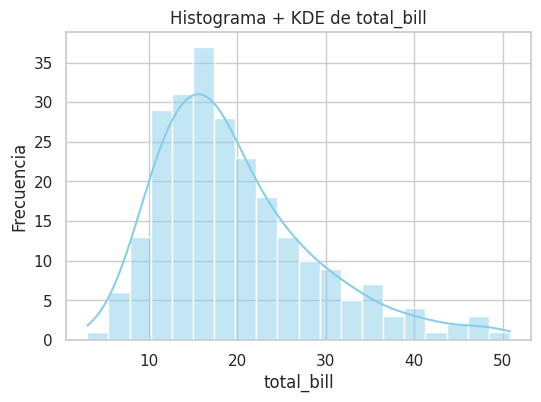

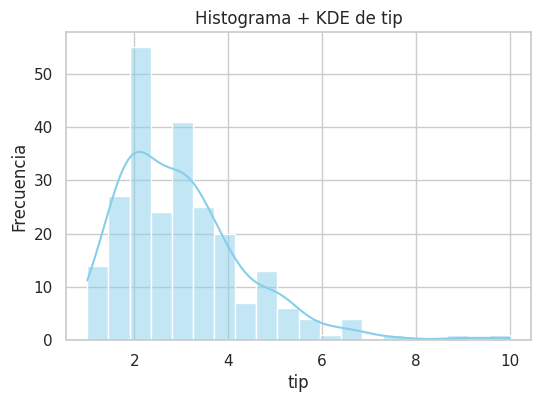

In [ ]:
# 2. Histogramas + KDE para montos de propina (tip) y total_bill
for col in ['total_bill', 'tip']:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=20, color='skyblue')
    plt.title(f"Histograma + KDE de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

In [ ]:
# 3. Cálculo de IQR y detección de outliers en "tip"
Q1 = df['tip'].quantile(0.25)
Q3 = df['tip'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
print(f"Tip: Q1={Q1}, Q3={Q3}, IQR={IQR}")
print("Outliers en tip:\n", df[(df['tip']<lower)|(df['tip']>upper)], "\n")
outliers = df[(df['tip'] < lower) | (df['tip'] > upper)]
print("Outliers en tip:\n", outliers, "\n")

Tip: Q1=2.0, Q3=3.5625, IQR=1.5625
Outliers en tip:
      total_bill    tip     sex smoker   day    time  size
23        39.42   7.58    Male     No   Sat  Dinner     4
47        32.40   6.00    Male     No   Sun  Dinner     4
59        48.27   6.73    Male     No   Sat  Dinner     4
141       34.30   6.70    Male     No  Thur   Lunch     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3
183       23.17   6.50    Male    Yes   Sun  Dinner     4
212       48.33   9.00    Male     No   Sat  Dinner     4
214       28.17   6.50  Female    Yes   Sat  Dinner     3
239       29.03   5.92    Male     No   Sat  Dinner     3 

Outliers en tip:
      total_bill    tip     sex smoker   day    time  size
23        39.42   7.58    Male     No   Sat  Dinner     4
47        32.40   6.00    Male     No   Sun  Dinner     4
59        48.27   6.73    Male     No   Sat  Dinner     4
141       34.30   6.70    Male     No  Thur   Lunch     6
170       50.81  10.00    Male    Yes   Sat  Dinner     3

Q1 (percentil 25%) = 2.0: El 25% de las propinas son menores o iguales a $2.00.

Q3 (percentil 75%) = 3.5625: El 75% de las propinas son menores o iguales a $3.56.

IQR = Q3 - Q1 = 1.5625: Es la dispersión entre los cuartiles.

Límites para outliers
Límite inferior (lower) = 2.0 - 1.5 * 1.5625 = -0.34375

Límite superior (upper) = 3.5625 + 1.5 * 1.5625 = 5.90625

Todos los valores de tip menores a -0.34 o mayores a 5.91 se consideran outliers.

Se detectaron 9 propinas como outliers por ser mayores a $5.91.

Estos valores son atípicos comparados con la mayoría de las propinas, lo que podría indicar:

Clientes muy generosos

Cuentas altas donde la propina proporcional es mayor

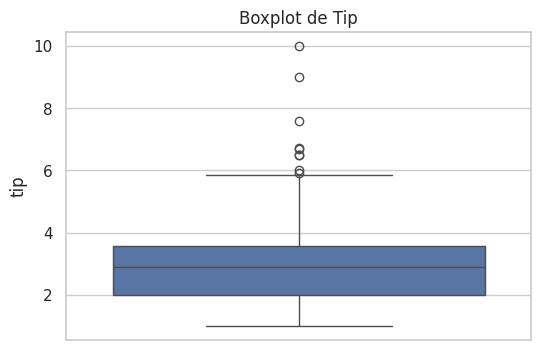

In [ ]:
# 4. Boxplot de "tip"
plt.figure(figsize=(6,4))
sns.boxplot(df['tip'])
plt.title("Boxplot de Tip")
plt.show()

In [ ]:
# 5. Tabla de frecuencias para "tip"
n = len(df)
k = int(np.ceil(1 + 3.322*np.log10(n)))
amp = np.ceil((df['tip'].max()-df['tip'].min())/k)
bins = np.arange(df['tip'].min(), df['tip'].max()+amp, amp)
labels = [f"[{round(b,2)}, {round(b+amp,2)})" for b in bins[:-1]]
df['clase_tip'] = pd.cut(df['tip'], bins=bins, labels=labels, include_lowest=True)
tabla = df['clase_tip'].value_counts().sort_index().reset_index()
tabla.columns = ['Clase','frec_abs']
tabla['frec_rel'] = (tabla['frec_abs']/n).round(4)
tabla['frec_acum'] = tabla['frec_abs'].cumsum()
tabla['frec_rel_acum'] = tabla['frec_rel'].cumsum().round(4)
print("Tabla de frecuencias (tip):\n", tabla, "\n")

Tabla de frecuencias (tip):
          Clase  frec_abs  frec_rel  frec_acum  frec_rel_acum
0   [1.0, 2.0)        78    0.3197         78         0.3197
1   [2.0, 3.0)        68    0.2787        146         0.5984
2   [3.0, 4.0)        57    0.2336        203         0.8320
3   [4.0, 5.0)        23    0.0943        226         0.9263
4   [5.0, 6.0)        11    0.0451        237         0.9714
5   [6.0, 7.0)         4    0.0164        241         0.9878
6   [7.0, 8.0)         1    0.0041        242         0.9919
7   [8.0, 9.0)         1    0.0041        243         0.9960
8  [9.0, 10.0)         1    0.0041        244         1.0001 



In [ ]:
# 6. Coeficiente de variación
cv = df[['total_bill','tip']].std()/df[['total_bill','tip']].mean()*100
print("Coeficiente de variación (%):\n", cv.round(2), "\n")

Coeficiente de variación (%):
 total_bill    44.99
tip           46.15
dtype: float64 



In [ ]:
# 7. Promedios agrupados
print("Promedio de propina según sexo:\n", df.groupby('sex')['tip'].mean(), "\n")
print("Promedio de propina según día de semana:\n", df.groupby('day')['tip'].mean(), "\n")

Promedio de propina según sexo:
 sex
Female    2.833448
Male      3.089618
Name: tip, dtype: float64 

Promedio de propina según día de semana:
 day
Fri     2.734737
Sat     2.993103
Sun     3.255132
Thur    2.771452
Name: tip, dtype: float64 



In [ ]:
# 0. Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
# 2. Regresión lineal múltiple (incluye variables categóricas automáticamente)
modelo = smf.ols('tip ~ total_bill + size + sex + smoker + day + time', data=df).fit()

# 3. Resumen completo del modelo
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.452
Method:                 Least Squares   F-statistic:                     26.06
Date:                Fri, 27 Jun 2025   Prob (F-statistic):           1.20e-28
Time:                        15:55:37   Log-Likelihood:                -347.48
No. Observations:                 244   AIC:                             713.0
Df Residuals:                     235   BIC:                             744.4
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept         0.8038      0.353      2.279

In [ ]:
# 3. Calcular matriz de correlación
# 1. Seleccionar columnas numéricas
df_numeric = df.select_dtypes(include=[np.number])

# 2. Calcular matriz de correlación
correlation_matrix = df_numeric.corr()

# 3. Mostrar matriz de correlación
print("Matriz de correlación:\n", correlation_matrix)

Matriz de correlación:
             total_bill       tip      size
total_bill    1.000000  0.675734  0.598315
tip           0.675734  1.000000  0.489299
size          0.598315  0.489299  1.000000


Las variables categóricas se transforman automáticamente en variables dummy (0 y 1) en statsmodels cuando usas la fórmula ('tip ~ var1 + var2 + var3').
Esto es lo que permite que se incluyan variables como sex, day, time, etc.

Coeficientes: muestran el impacto esperado en la propina (tip) al aumentar en una unidad la variable (cuantitativa) o cambiar de categoría (dummy).

Ejemplo:

total_bill = 0.0945: por cada dólar adicional en la cuenta, se espera que la propina aumente $0.0945, manteniendo las demás variables constantes.

sex[T.Male] = -0.0324: los hombres tienden a dejar $0.0324 menos en propina comparado con las mujeres (aunque no es significativo).

p-valor (P>|t|): si es menor a 0.05, el efecto es estadísticamente significativo.

Aquí solo total_bill y apenas size (con p ≈ 0.051) son significativas.

R² = 0.470: el modelo explica el 47% de la variabilidad en las propinas.

ANOVA (F-statistic):

F = 26.06, Prob(F) ≈ 1.20e-28: indica que el modelo como un todo es altamente significativo.



In [ ]:
# Modelo reducido con solo variables significativas al 10%
modelo_reducido = smf.ols('tip ~ total_bill + size', data=df).fit()

# Resumen del modelo
print(modelo_reducido.summary())

                            OLS Regression Results                            
Dep. Variable:                    tip   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     105.9
Date:                Fri, 27 Jun 2025   Prob (F-statistic):           9.67e-34
Time:                        15:00:40   Log-Likelihood:                -347.99
No. Observations:                 244   AIC:                             702.0
Df Residuals:                     241   BIC:                             712.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.6689      0.194      3.455      0.0

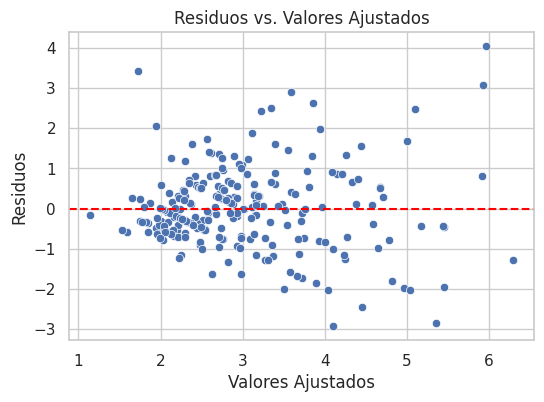

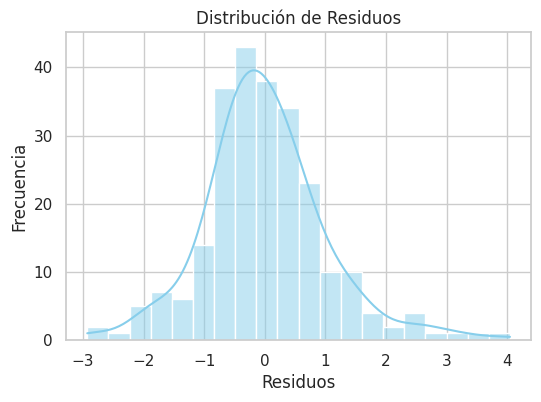

<Figure size 600x400 with 0 Axes>

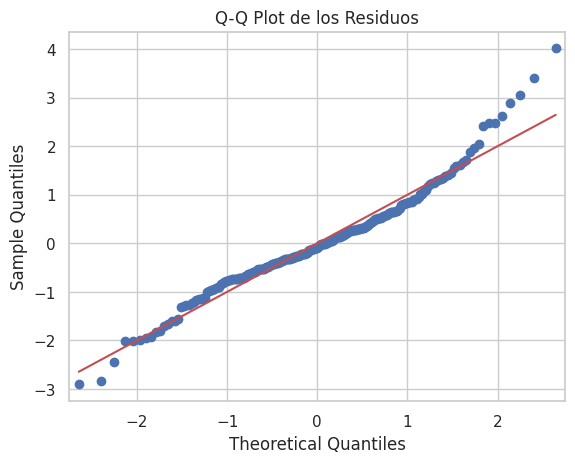

In [ ]:
import scipy.stats as stats
# 2. Obtener residuos y valores ajustados
residuos = modelo_reducido.resid
ajustados = modelo_reducido.fittedvalues

# 3. Gráfico: Residuos vs. Valores Ajustados
plt.figure(figsize=(6, 4))
sns.scatterplot(x=ajustados, y=residuos)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Valores Ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs. Valores Ajustados")
plt.show()

# 4. Histograma de residuos
plt.figure(figsize=(6, 4))
sns.histplot(residuos, kde=True, color='skyblue', bins=20)
plt.title("Distribución de Residuos")
plt.xlabel("Residuos")
plt.ylabel("Frecuencia")
plt.show()

# 5. Q-Q Plot (Normalidad de residuos)
plt.figure(figsize=(6, 4))
sm.qqplot(residuos, line='s', fit=True)
plt.title("Q-Q Plot de los Residuos")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

# 1. Crear copia del DataFrame original
df_encoded = df.copy()

# 2. Codificar variables categóricas
df_encoded['sex'] = df_encoded['sex'].map({'Female': 0, 'Male': 1})
df_encoded['day'] = df_encoded['day'].map({'Thur': 0, 'Fri': 1, 'Sat': 2, 'Sun': 3})
df_encoded['smoker'] = df_encoded['smoker'].map({'No': 0, 'Yes': 1})
df_encoded['time'] = df_encoded['time'].map({'Lunch': 0, 'Dinner': 1})

# 3. Seleccionar solo columnas numéricas
df_corr = df_encoded.select_dtypes(include=[np.number])

# 4. Calcular la matriz de correlación
correlation_matrix = df_corr.corr().round(3)

# 5. Mostrar resultados
print("Matriz de correlación con variables categóricas codificadas:\n", correlation_matrix)

Matriz de correlación con variables categóricas codificadas:
             total_bill    tip    sex  smoker    day   time   size
total_bill       1.000  0.676  0.145   0.086  0.174  0.183  0.598
tip              0.676  1.000  0.089   0.006  0.135  0.122  0.489
sex              0.145  0.089  1.000   0.003  0.231  0.205  0.086
smoker           0.086  0.006  0.003   1.000 -0.033  0.055 -0.133
day              0.174  0.135  0.231  -0.033  1.000  0.874  0.165
time             0.183  0.122  0.205   0.055  0.874  1.000  0.103
size             0.598  0.489  0.086  -0.133  0.165  0.103  1.000


In [ ]:
# Tarea grupal
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Cargar la base de datos desde GitHub
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/penguins.csv"
df = pd.read_csv(url)
df.head()
# Esta base contiene información sobre pingüinos de tres especies, recolectada en el archipiélago Palmer (Antártida)
# por el Palmer Station LTER.
# Variable	Tipo	Descripción
# species	Cualitativa nominal	Especie del pingüino: Adelie, Gentoo o Chinstrap
# island	Cualitativa nominal	Isla de procedencia: Biscoe, Dream o Torgersen.
# bill_length_mm	Cuantitativa continua	Longitud del pico del pingüino en milímetros.
# bill_depth_mm	Cuantitativa continua	Profundidad del pico en milímetros.
# flipper_length_mm	Cuantitativa continua	Longitud de las aletas en milímetros.
# body_mass_g	Cuantitativa continua	Masa corporal en gramos.
# sex	Cualitativa nominal	Sexo del pingüino: Male o Female.
# year	Cualitativa ordinal/discreta	Año en que se registró el dato: 2007, 2008 o 2009. Puede verse como ordinal.


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


**Parte I Clasificación de variables**
Pregunta 1:
Clasifica las variables del DataFrame en:

Cualitativas nominales

Cualitativas ordinales (si aplica)

Cuantitativas continuas o discretas.

**Parte II Análisis de variable cuantitativa**
Pregunta 2:
Selecciona una variable cuantitativa, por ejemplo, body_mass_g:

Elabora una tabla de frecuencias completa (clases, frecuencias absolutas, relativas y acumuladas).

Crea un histograma + KDE.

Interpreta la asimetría de la distribución.

Detecta outliers usando el método del IQR.

**Parte III Estadísticos descriptivos**
Pregunta 3:
Para la variable flipper_length_mm, calcula:

Media, mediana, moda

Desviación estándar, rango y coeficiente de variación.

**Parte IV Análisis de variable cualitativa**
Pregunta 4:
Realiza un gráfico de barras para species y para island. Luego responde:

¿Qué especie es más frecuente?

¿Qué isla tiene más registros?

¿Hay diferencia en la masa corporal promedio (body_mass_g) entre especies?.

** Parte V Comparación de promedios por grupo**
Pregunta 5:
Agrupa por sex y calcula el promedio de las siguientes variables:

bill_length_mm

flipper_length_mm

body_mass_g

Interpreta si hay diferencias notables.

**Parte VI Regresión Lineal Múltiple**
Pregunta 6:
Realiza una regresión lineal múltiple donde la variable dependiente sea body_mass_g, y las independientes sean:

bill_length_mm

flipper_length_mm

species, island, sex (convertidas en variables dummies)


**Pregunta 7:**

¿Qué variables son significativas al 10%?

¿Qué tanto explica el modelo? (R²)

¿Cómo interpretas el coeficiente de flipper_length_mm?

